In [1]:
import seaborn as sns

titanic = sns.load_dataset('titanic')

titanic.head()
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


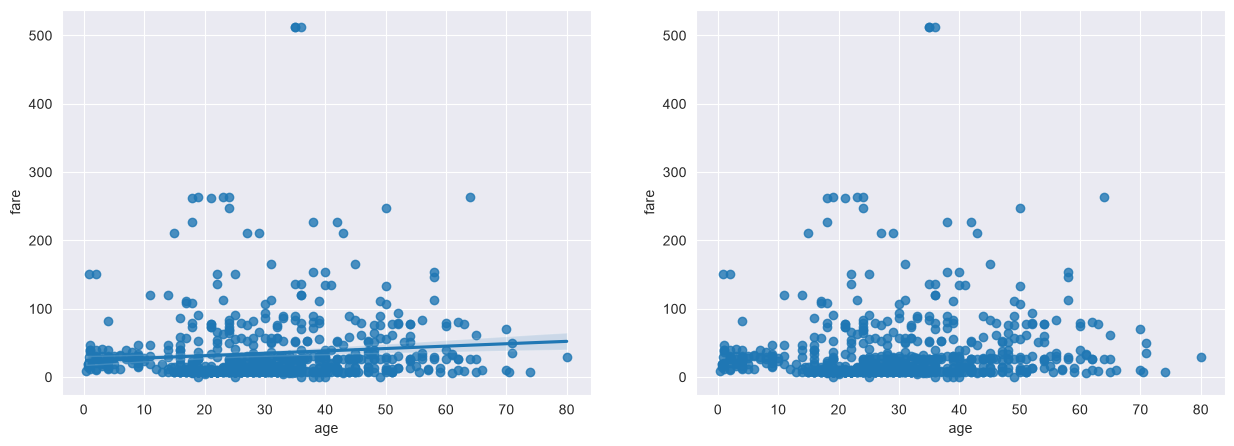

In [2]:
# 회귀선이 있는 산점도
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    x='age',
    y='fare',
    data=titanic,
    ax=axes[0]
)

sns.regplot(
    x='age',
    y='fare',
    data=titanic,
    ax=axes[1],
    fit_reg=False
)

plt.show()

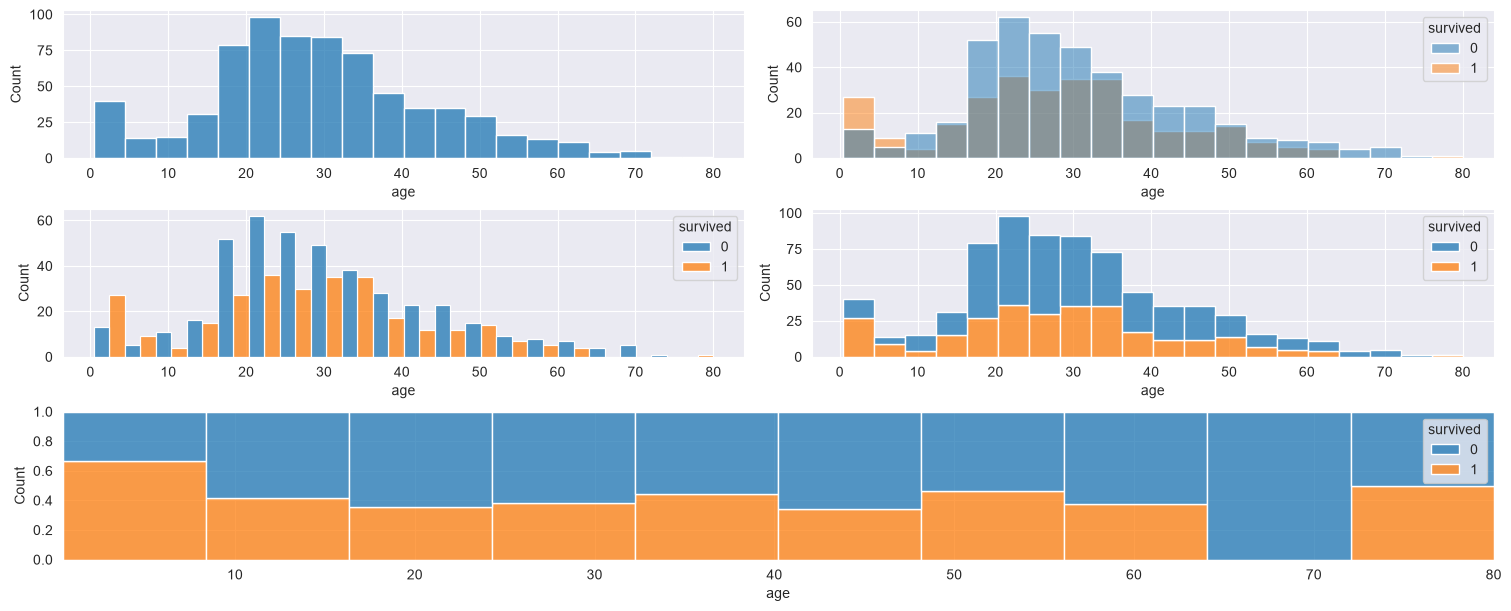

In [3]:
# 히스토그램/커널 밀도 함수
fig, axes = plt.subplot_mosaic(
    [
        ['top_left', 'top_right'], 
        ['middle_left', 'middle_right'],
        ['bottom', 'bottom']
    ],
    figsize=(15, 6),
    constrained_layout=True
)

sns.histplot(
    x='age',
    data=titanic,
    ax=axes['top_left']
)

sns.histplot(
    x='age',
    data=titanic,
    hue='survived',
    ax=axes['top_right']
)

sns.histplot(
    x='age',
    data=titanic,
    hue='survived',
    multiple='dodge',
    ax=axes['middle_left']
)

sns.histplot(
    x='age',
    data=titanic,
    hue='survived',
    multiple='stack',
    ax=axes['middle_right']
)

sns.histplot(
    x='age',
    data=titanic,
    hue='survived',
    multiple='fill',
    bins=10,
    ax=axes['bottom']
)

plt.show()

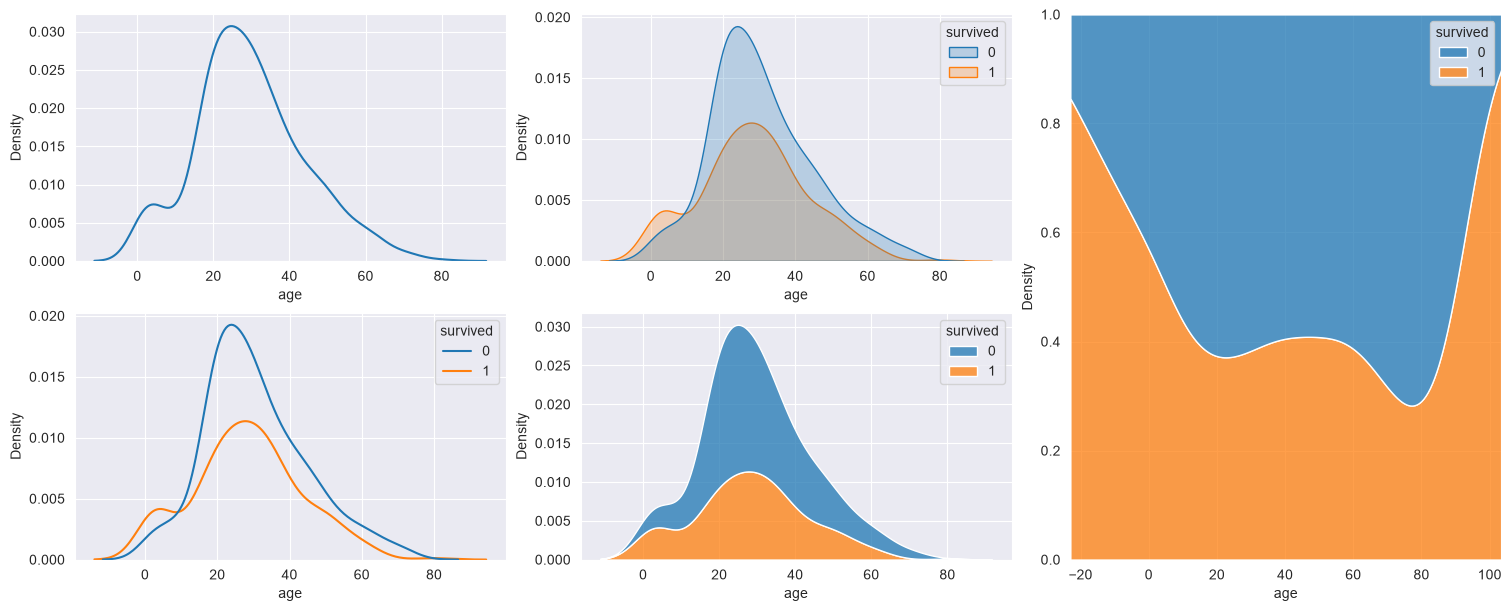

In [4]:
fig, axes = plt.subplot_mosaic(
    [
        ['top_left', 'top_center', 'right'],
        ['bottom_left', 'bottom_center', 'right'],
    ],
    figsize=(15, 6),
    constrained_layout=True
)

sns.kdeplot(
    x='age',
    data=titanic,
    ax=axes['top_left'],
)

sns.kdeplot(
    x='age',
    data=titanic,
    hue='survived',
    ax=axes['bottom_left'],
)

sns.kdeplot(
    x='age',
    data=titanic,
    hue='survived',
    fill=True,
    ax=axes['top_center'],
)

sns.kdeplot(
    x='age',
    data=titanic,
    hue='survived',
    multiple='stack',
    ax=axes['bottom_center'],
)

sns.kdeplot(
    x='age',
    data=titanic,
    hue='survived',
    multiple='fill',
    bw_adjust=2,    # 굴곡 완만
    ax=axes['right'],
)

plt.show()

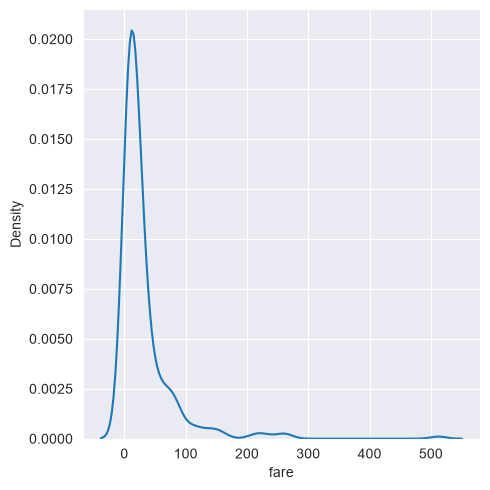

In [5]:
# sns.displot(
#     titanic['fare'],
#     kind='hist',
# )

sns.displot(
    titanic['fare'],
    kind='kde',
)

plt.show()

In [6]:
titanic['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

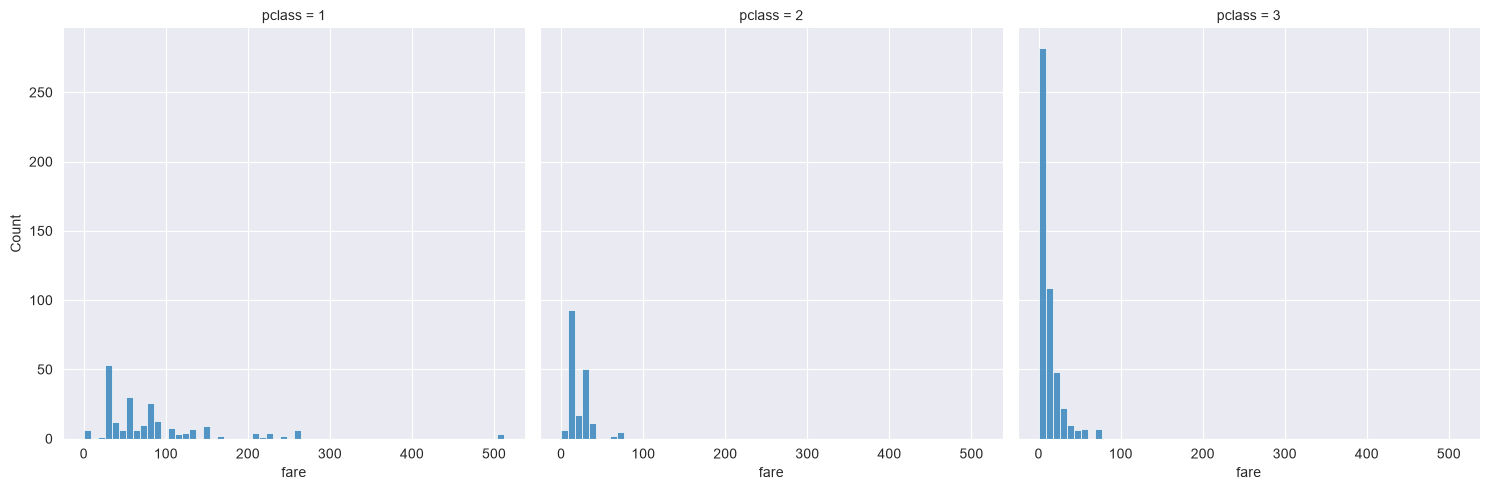

In [7]:
sns.displot(
    data=titanic,
    x='fare',
    col='pclass',
    kind='hist',
)

plt.show()

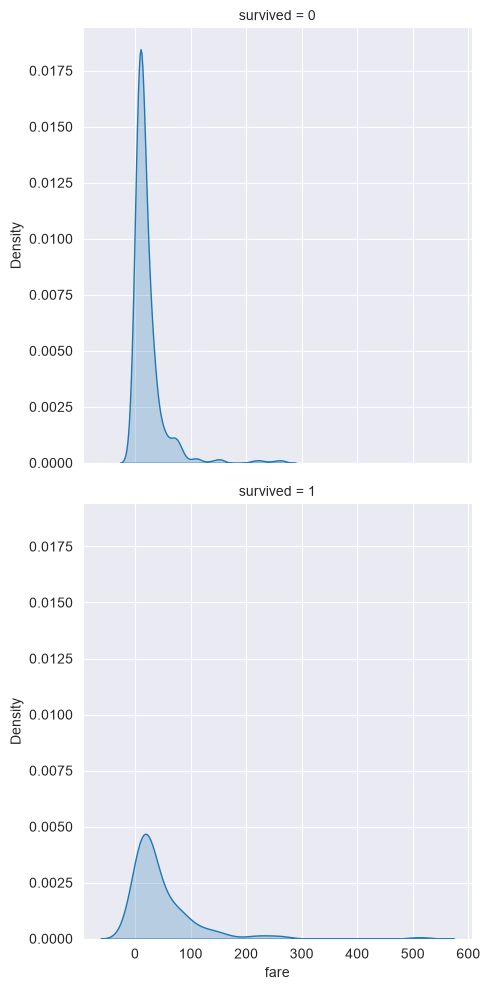

In [8]:
sns.displot(
    data=titanic,
    x='fare',
    row='survived',
    kind='kde',
    fill=True
)

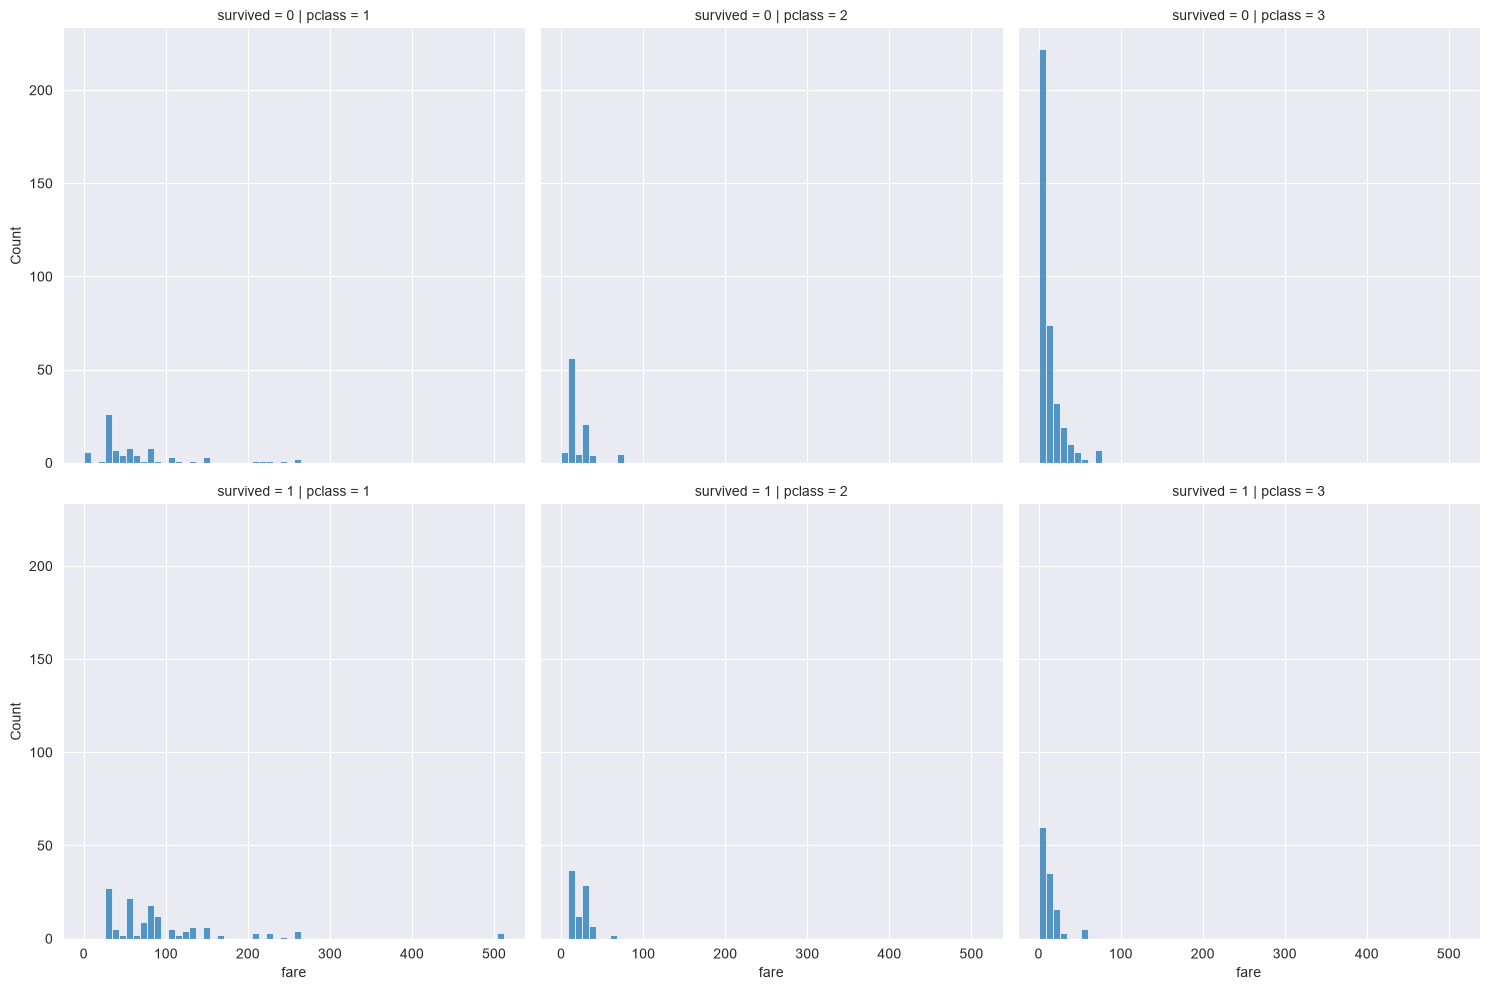

In [9]:
sns.displot(
    data=titanic,
    x='fare',
    col='pclass',
    row='survived',
)

plt.show()

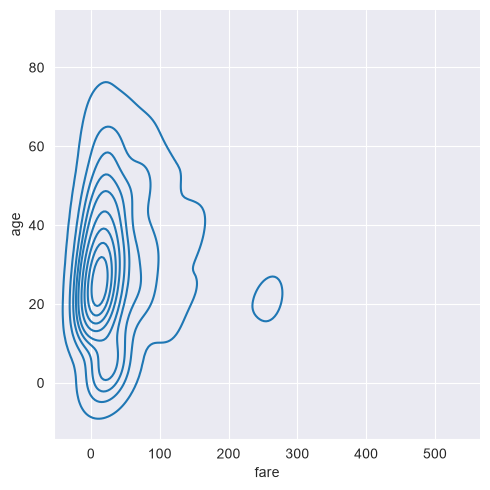

In [17]:
sns.displot(
    x='fare',
    y='age',
    data=titanic,
    kind='kde',
)

plt.show()

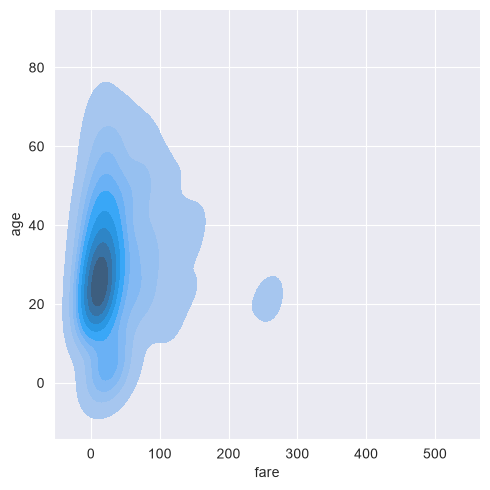

In [18]:
sns.displot(
    x='fare',
    y='age',
    data=titanic,
    kind='kde',
    fill=True
)

plt.show()

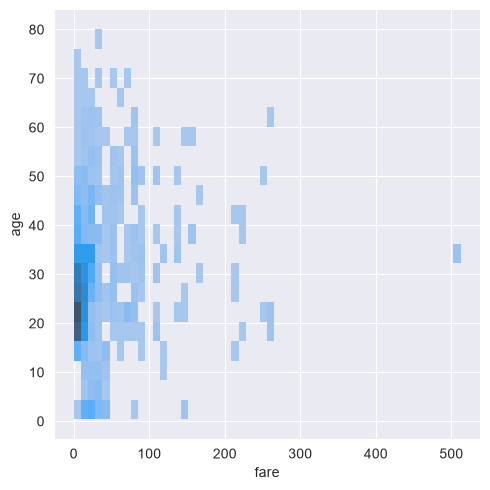

In [19]:
sns.displot(
    x='fare',
    y='age',
    data=titanic,
    kind='hist',
)

plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')

sns.set_style('darkgrid')

table = titanic.pivot_table(
    index=['sex'],
    columns=['class'],
    aggfunc='size',     # 집계 함수
    observed=False
)

print(type(table))
print(table)

<class 'pandas.DataFrame'>
class   First  Second  Third
sex                         
female     94      76    144
male      122     108    347


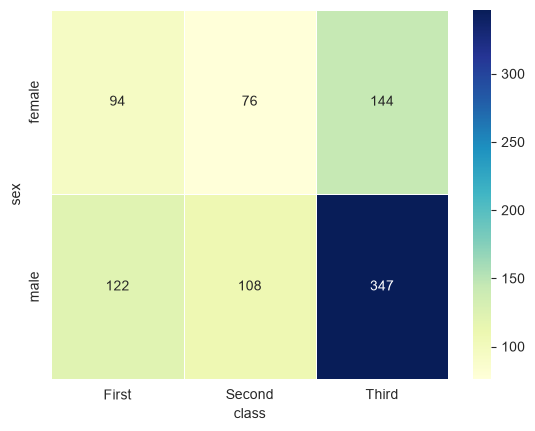

In [33]:
sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=.5,
    cbar=True
)

plt.show()

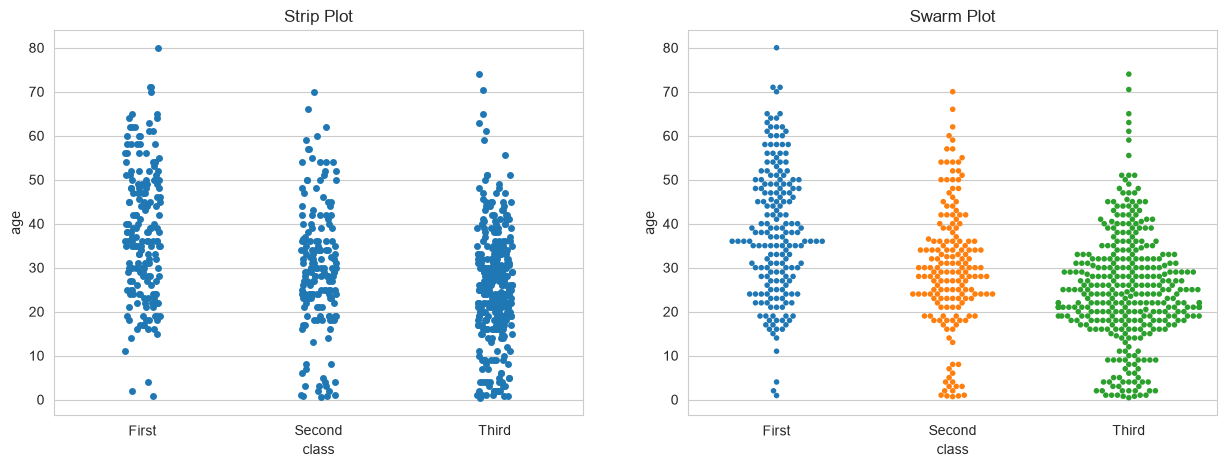

In [41]:
# 범주형 데이터의 산점도
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(
    x='class',
    y='age',
    data=titanic,
    ax=axes[0]
)

sns.swarmplot(
    x='class',
    y='age',
    data=titanic,
    ax=axes[1],
    hue='class',    # 색상은 class별로
    size=4
)

axes[0].set_title('Strip Plot')
axes[1].set_title('Swarm Plot')

plt.show()